In [1]:
author="Jumabek Alikhanov"
date = 'Nov 22,2019'

### Dataset can be downloaded from https://www.unb.ca/cic/datasets/ids-2017.html or you can directly below shell
You need to just unzip and put it same directory with this CNN.ipynb file

### Download dataset directly and unzip

In [2]:
#!gdown --id 1-t3RdDpmqMs4ABt9oobSapeNYTZJ9tpu
#!unzip MachineLearningCSV.zip

In [3]:
import os
from os.path import join
import glob
import pandas as pd
import numpy as np
import time
from preprocessing import balance_data, normalize,load_data
%load_ext autoreload

In [4]:
SEED = 2
import numpy as np
import torch

np.random.seed(SEED)
torch.manual_seed(SEED)


### Set dataset path

In [5]:

dataroot = 'MachineLearningCVE/'

In [6]:
%autoreload 2
X,y = load_data(dataroot) # reads csv file and returns np array of X,y -> of shape (N,D) and (N,1)

MachineLearningCVE/*.csv
['MachineLearningCVE\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'MachineLearningCVE\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'MachineLearningCVE\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'MachineLearningCVE\\Monday-WorkingHours.pcap_ISCX.csv', 'MachineLearningCVE\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'MachineLearningCVE\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'MachineLearningCVE\\Tuesday-WorkingHours.pcap_ISCX.csv', 'MachineLearningCVE\\Wednesday-workingHours.pcap_ISCX.csv']
There are 2830743 flow records with 79 feature dimension
Data loaded.
Data preprocessing started...
Stripped column names with whitespaces
remove unnecessary columns:  ['Flow Packets/s', 'Flow Bytes/s', 'Label']
There are 0 nan entries
Converted to numeric


## Data Imbalance
1. It is curucial to adress this issue in order to get decent performance
2. It also affects evaluation, we should calculate  `balanced accuracy`

In [7]:

X = normalize(X)

Set random seed

#### X and y dataset shapes

In [8]:
print(X.shape)
print(y.shape)

(2830743, 76)
(2830743,)


In [9]:

%autoreload 2
from models import Classifier

def ensure_dir(dir_path):
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

def getClassifier(args,runs_dir=None):
    
    (method,optim,lr,reg,batch_size,input_dim,num_class,num_epochs) = args
    if runs_dir is not None:
        ensure_dir(runs_dir)
    
    clf = Classifier(method,input_dim,num_class,lr=lr,reg=reg,num_epochs=num_epochs,
                        batch_size=batch_size,runs_dir=runs_dir)
    return clf


In [10]:
all_y_true = []
all_y_pred = []

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn import metrics
K=5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
for fold_index, (train_index,test_index) in enumerate(skf.split(X,y)):# runs only once 
        print('---------------------------------------------')
        print('Fold #{}'.format(fold_index))    
        X_train = X[train_index]
        y_train = y[train_index]
        X_test = X[test_index]
        y_test = y[test_index]
        break

---------------------------------------------
Fold #0


In [12]:

#hyper-params
batch_size = 5*1024 # increasing batch size with more gpu added
optim = 'Adam'

input_dim = X_train.shape[1]
num_class = len(np.unique(y_train))
num_epochs = 60
learning_rates = [1e-3]
regularizations = [1e-3]


accuracies = {}
best_model = None
best_acc = -1
architecture = '1D-CNN_conv_5_fc_1'
run_number = 5
method='cnn5'

for lr in learning_rates:
    for reg in regularizations:

        classifier_args = (method,optim,lr,reg,batch_size,input_dim,num_class,num_epochs)
        config =  '{}/{}th_run/optim_{}_lr_{}_reg_{}_bs_{}'.format(architecture,run_number,optim,lr,reg,batch_size)
        runs_dir = join(dataroot,'runs',config)
        
        X_train = X_train.astype(float)
        y_train = y_train.astype(int)
        p = np.random.permutation(len(y_train))
        X_train = X_train[p]
        y_train = y_train[p]
        X_train,y_train = balance_data(X_train,y_train,seed=SEED)

        tick = time.time()
        clf = getClassifier(classifier_args,runs_dir)
        
        clf.fit(X_train,y_train)
        pred = clf.predict(X_test,eval_mode=True)

        all_y_true.extend(y_test.reshape(-1))
        all_y_pred.extend(pred.reshape(-1))

        acc = metrics.balanced_accuracy_score(y_test,pred)
        if acc >best_acc:
            best_model = clf
            best_acc = acc
        accuracies[(lr,reg)]=acc
        tock = time.time()
        print("Model is trained in {} sec".format(tock-tick))

Loaded MachineLearningCVE/runs\1D-CNN_conv_5_fc_1/5th_run/optim_Adam_lr_0.001_reg_0.001_bs_5120 model trained with batch_size = 5120, seen 1 epochs and 50 mini batches
Loaded MachineLearningCVE/runs\1D-CNN_conv_5_fc_1/5th_run/optim_Adam_lr_0.001_reg_0.001_bs_5120 model trained with batch_size = 5120, seen 3 epochs and 252 mini batches
Model is trained in 737.87757396698 sec


In [13]:
# accuracies for CV
for x in accuracies:
    print(x)
    print(accuracies[x])
results = accuracies  

(0.001, 0.001)
0.8776339776785054


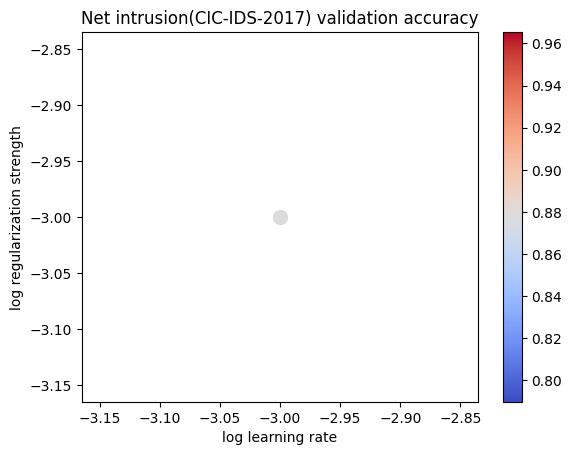

In [14]:
# Visualize the cross-validation results
import math
import matplotlib.pyplot as plt
x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]


# plot validation accuracy
marker_size=100
colors = [results[x] for x in results] # default size of markers is 20

plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('Net intrusion(CIC-IDS-2017) validation accuracy')
plt.savefig('MachineLearningCVE/method_{}_arch_run_{}-2.png'.format(method,architecture,run_number))
plt.show()

In [15]:
print(X.shape)
print(np.unique(y, return_counts=True))


(2830743, 76)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([2273097,    1966,  128027,   10293,  231073,    5499,    5796,
          7938,      11,      36,  158930,    5897,    1507,      21,
           652]))


In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

y_true = np.array(all_y_true)
y_pred = np.array(all_y_pred)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))



Accuracy: 0.9446329499831316
Precision: 0.9781050969583731
Recall: 0.9446329499831316
F1-score: 0.9590555141271837

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    454620
           1       0.04      1.00      0.07       393
           2       0.97      1.00      0.98     25605
           3       0.83      1.00      0.90      2059
           4       0.93      1.00      0.96     46214
           5       0.72      0.99      0.84      1100
           6       0.81      0.99      0.89      1159
           7       0.80      1.00      0.89      1587
           8       0.22      1.00      0.36         2
           9       0.00      0.62      0.00         8
          10       0.82      1.00      0.90     31786
          11       0.46      0.99      0.63      1180
          12       0.13      0.46      0.20       301
          13       0.00      0.40      0.01         5
          14       0.05      0.79      0.10       

In [17]:
# ===============================
# Save best baseline CNN model
# ===============================

import torch

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_dir,
    "baseline_cnn_cicids2017.pth"
)

torch.save({
    "model_state_dict": best_model.model.state_dict(),
    "architecture": "1D-CNN_conv5_fc1",
    "dataset": "CIC-IDS-2017 (MachineLearningCVE)",
    "seed": SEED,
    "accuracy": best_acc
}, checkpoint_path)

print("Baseline model checkpoint saved to:")
print(checkpoint_path)


Baseline model checkpoint saved to:
checkpoints\baseline_cnn_cicids2017.pth
